# Задание 1
Реализовать вычисление энтропии и посчитать её значение для: 
- (0.2, 0.2, 0.2, 0.2, 0.2) 
- (0.5, 0.5) 
- (0.9, 0.05, 0.05, 0) 
- (0, 0, 0, 0, 1, 0)

Объяснить полученные результаты

In [52]:
label1 = [0.2, 0.2, 0.2, 0.2, 0.2]
label2 = [0.5, 0.5]
label3 = [0.9, 0.05, 0.05, 0]
label4 = [0, 0, 0, 0, 1, 0]

In [53]:
import pandas as pd
from functools import reduce
import math

In [54]:
def entropy (label):
  df = pd.DataFrame(label)
  ent = lambda df:-reduce(lambda x,y:x+y,map(lambda x:(x/len(df))*math.log2(x/len(df)),df.iloc[:,-1].value_counts()))
  return ent(df)

print(entropy(label1))
print(entropy(label2))
print(entropy(label3))
print(entropy(label4))

-0.0
-0.0
1.5
0.6500224216483541


# Задание 2

- Напишите класс дерева, который реализует метод train, получающий на вход матрицу данных (𝑥) и целевые переменные (𝑦), на выходе функция возвращает дерево в виде словаря
- в каждом случае записывается номер признака (𝑖), порог разбиения(𝑡), значение в листовой вершине слева (𝑦𝑙) и значение в листовой вершине справа (𝑦𝑟). 
- Вместо значения в листовой вершине может содержаться следующий словарь с теми же ключами и так далее

Необходимо учесть:

- Возможность строить дерево строго определенной глубины и возможность указать максимальное количество объектов в листовой вершине.
- Пороги разбиения должны лежать строго по середине между ближайшими обектами.
- Разбиений не требуется, если в получившемся множестве находятся объекты одного класса.
- Количество различных классов объектов в целевой переменной может быть больше двух.



- Постройте решающее дерево с глубиной 1, 2 и 3.
- Также постройте дерево максимальной глубины
- Визуализируйте получившиеся результаты классификатора на плоскости (код есть в предыдущих лабах)

# Задание 3
Выполните задание 2 с помощью sklearn

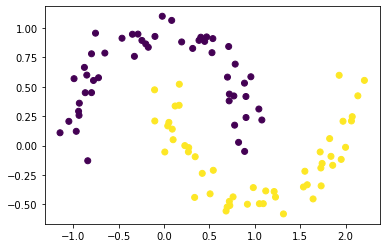

In [55]:
from sklearn.datasets import make_blobs, make_moons
import matplotlib.pyplot as plt
import numpy as np


x, y = make_moons(n_samples=100, noise=0.1)
plt.scatter(x[:,0], x[:,1], c = y);

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

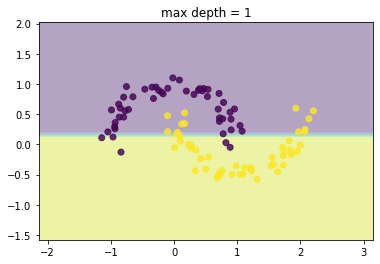

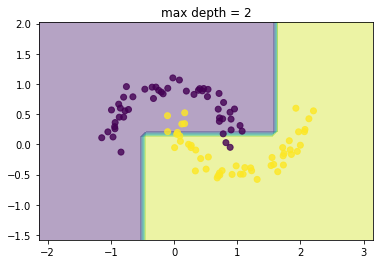

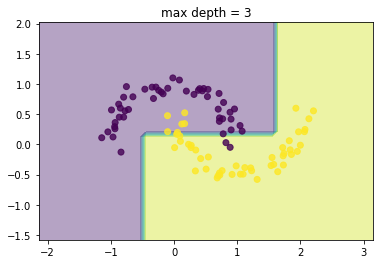

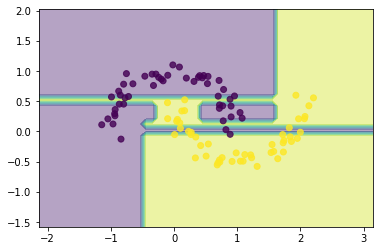

In [57]:
for k in range(1, 4):
    clf = DecisionTreeClassifier(max_depth=k)
    clf.fit(x_train, y_train)
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(x[:, 0], x[:, 1], c=y, alpha=0.8)
    plt.title(f'max depth = {k}')
    plt.show()

clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(x[:, 0], x[:, 1], c=y, alpha=0.8)
plt.show()